# Data quality EDA: arXiv ingestion output (issue #8)

Checks the structure and integrity of `data/papers.parquet` before anything is built on it. This notebook is about whether the data is **correct**: types, missing values, duplicates, and fields that don't agree with each other. Text structure, chunking, and preprocessing are covered in `eda_corpus.ipynb`.

Five questions this notebook answers:

1. **Does the data match the schema the pipeline promises?** Columns, types, and what's actually stored in each cell.
2. **What's missing?** Nulls, but also empty strings and empty lists, which `isna()` doesn't catch.
3. **Do the fields agree with each other?** Status columns vs. actual text, PDFs on disk, URLs vs. IDs.
4. **Is anything duplicated?** Same ID, same paper under a new version, same title, same abstract, same text.
5. **Are the values valid?** ID and category formats, dates, author names.

Run top to bottom from `notebooks/`. The findings table at the end is generated from the numbers above it, so it never goes out of date. If `data/papers_clean.parquet` exists, §7 runs the same checks on the preprocessed output.

## 0. Setup

In [21]:
import hashlib, re, warnings
from collections import Counter
from difflib import SequenceMatcher
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["figure.dpi"] = 110

ROOT = Path("..")                        # project root, relative to notebooks/
DATASET_PATH = ROOT / "data/papers.parquet"
CLEAN_PATH = ROOT / "data/papers_clean.parquet"
FIG_DIR = ROOT / "reports/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATASET_PATH)
F = {}   # every number the findings table uses gets stored here
F["rows"] = len(df)
F["date_min"], F["date_max"] = df["published"].min(), df["published"].max()
print(f"{len(df):,} rows, {df.shape[1]} columns, {DATASET_PATH.stat().st_size / 1e6:.1f} MB on disk")
print(f"published: {F['date_min']} -> {F['date_max']}")

Matplotlib is building the font cache; this may take a moment.


201 rows, 15 columns, 8.0 MB on disk
published: 2026-09-25 13:04:09+00:00 -> 2026-09-28 04:00:12.122510+00:00


## 1. Schema: does the data match what the pipeline promises?

`df.dtypes` only says `object` for the list columns and can't tell a string from a list. So I check the dtype pandas reports and the Python type actually stored in each cell against what `src/ingestion` is supposed to write.

In [22]:
# what src/ingestion is supposed to produce: column -> (pandas dtype family, python type in each cell)
SCHEMA = {
    "arxiv_id": ("string", str), "title": ("string", str), "abstract": ("string", str),
    "authors": ("object", (list, np.ndarray)), "primary_category": ("string", str),
    "categories": ("object", (list, np.ndarray)),
    "published": ("datetime_utc", pd.Timestamp), "updated": ("datetime_utc", pd.Timestamp),
    "pdf_url": ("string", str), "abs_url": ("string", str), "pdf_path": ("string", str),
    "download_status": ("string", str), "extracted_text": ("string", str),
    "extraction_status": ("string", str), "ingestion_status": ("string", str),
}

def dtype_family(s):
    if isinstance(s.dtype, pd.DatetimeTZDtype):
        return "datetime_utc" if str(s.dtype.tz) == "UTC" else f"datetime_{s.dtype.tz}"
    if pd.api.types.is_datetime64_any_dtype(s):
        return "datetime_naive"
    if pd.api.types.is_string_dtype(s) and s.dropna().map(lambda v: isinstance(v, str)).all():
        return "string"
    return "object"

rows = []
for col in sorted(set(SCHEMA) | set(df.columns), key=lambda c: list(SCHEMA).index(c) if c in SCHEMA else 99):
    if col not in df:
        rows.append({"column": col, "status": "MISSING"}); continue
    s = df[col]
    exp_family, exp_type = SCHEMA.get(col, (None, None))
    wrong_type = int(s.dropna().map(lambda v: not isinstance(v, exp_type)).sum()) if exp_type else None
    rows.append({
        "column": col,
        "status": "unexpected" if col not in SCHEMA else "ok" if dtype_family(s) == exp_family and wrong_type == 0 else "MISMATCH",
        "expected": exp_family, "actual": dtype_family(s),
        "python types": ", ".join(sorted({type(v).__name__ for v in s.dropna()})) or "all null",
        "cells of wrong type": wrong_type,
    })
schema_df = pd.DataFrame(rows)
F["schema_problems"] = schema_df.loc[schema_df["status"] != "ok", "column"].tolist()
schema_df

,column,status,expected,actual,python types,cells of wrong type
0,arxiv_id,ok,string,string,str,0
1,title,ok,string,string,str,0
2,abstract,ok,string,string,str,0
3,authors,ok,object,object,ndarray,0
4,primary_category,ok,string,string,str,0
5,categories,ok,object,object,ndarray,0
6,published,ok,datetime_utc,datetime_utc,Timestamp,0
7,updated,ok,datetime_utc,datetime_utc,Timestamp,0
8,pdf_url,ok,string,string,str,0
9,abs_url,ok,string,string,str,0


In [23]:
# parquet hands list columns back as numpy arrays. They look like lists but break
# df.duplicated(), `in`, and == comparisons, so convert them once here.
for c in ["authors", "categories"]:
    df[c] = df[c].apply(lambda v: list(v) if isinstance(v, (list, np.ndarray)) else v)

## 2. Missing values

`isna()` only counts `None`/`NaN`. An empty title (`""`), a whitespace-only abstract, or an empty author list is just as missing, and it passes straight through `isna()`. This counts all three.

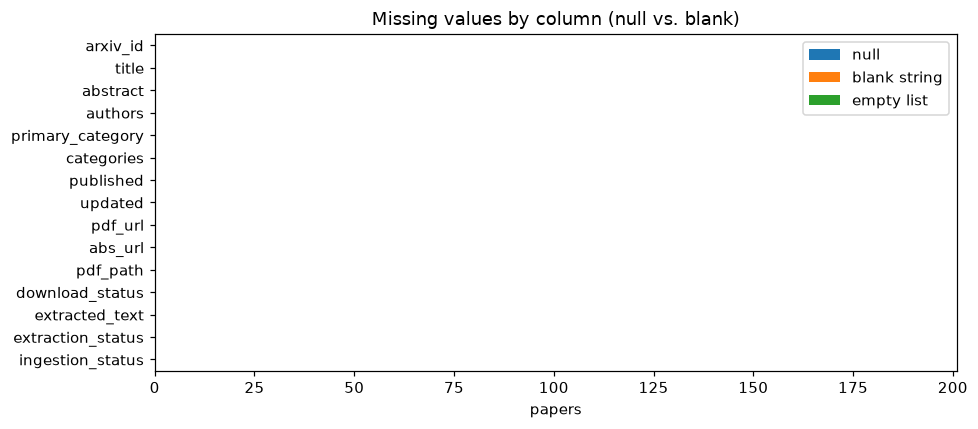

,null,blank string,empty list,total,pct
arxiv_id,0,0,0,0,0.0
title,0,0,0,0,0.0
abstract,0,0,0,0,0.0
authors,0,0,0,0,0.0
primary_category,0,0,0,0,0.0
categories,0,0,0,0,0.0
published,0,0,0,0,0.0
updated,0,0,0,0,0.0
pdf_url,0,0,0,0,0.0
abs_url,0,0,0,0,0.0


In [24]:
def kind_of_missing(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return "null"
    if isinstance(v, str) and not v.strip():
        return "blank string"
    if isinstance(v, (list, tuple, np.ndarray)) and len(v) == 0:
        return "empty list"
    return None

miss = pd.DataFrame({c: df[c].map(kind_of_missing).value_counts() for c in df.columns}).T.fillna(0).astype(int)
for k in ["null", "blank string", "empty list"]:
    if k not in miss: miss[k] = 0
miss = miss[["null", "blank string", "empty list"]]
miss["total"] = miss.sum(axis=1)
miss["pct"] = (miss["total"] / len(df) * 100).round(1)
miss = miss.sort_values("total", ascending=False)
F["missing"] = miss.loc[miss["total"] > 0, "total"].to_dict()
F["missing_hidden"] = int(miss[["blank string", "empty list"]].values.sum())  # what isna() would have missed

fig, ax = plt.subplots()
miss[["null", "blank string", "empty list"]].iloc[::-1].plot(kind="barh", stacked=True, ax=ax)
ax.set_title("Missing values by column (null vs. blank)")
ax.set_xlabel("papers"); ax.set_xlim(0, max(1, len(df)))
plt.tight_layout(); plt.savefig(FIG_DIR / "dq_missing_values.png"); plt.show()
miss

## 3. Consistency: do the fields agree with each other?

The status columns are what `get_ingested_ids` trusts when it decides what to skip on rerun. If a status says `complete` but the text or the PDF isn't really there, that paper is silently lost forever, because it will never be retried.

In [25]:
print(pd.crosstab([df["download_status"], df["extraction_status"]], df["ingestion_status"], margins=True), "\n")

ALLOWED = {
    "download_status": {"downloaded", "skipped_exists", "failed"},
    "extraction_status": {"extracted", "failed", "not_attempted"},
    "ingestion_status": {"complete", "partial", "failed"},
}
unexpected_values = {c: sorted(set(df[c].dropna()) - ok) for c, ok in ALLOWED.items() if set(df[c].dropna()) - ok}
print("status values outside the allowed set:", unexpected_values or "none")

ingestion_status                   complete  All
download_status extraction_status               
downloaded      extracted               201  201
All                                     201  201 

status values outside the allowed set: none


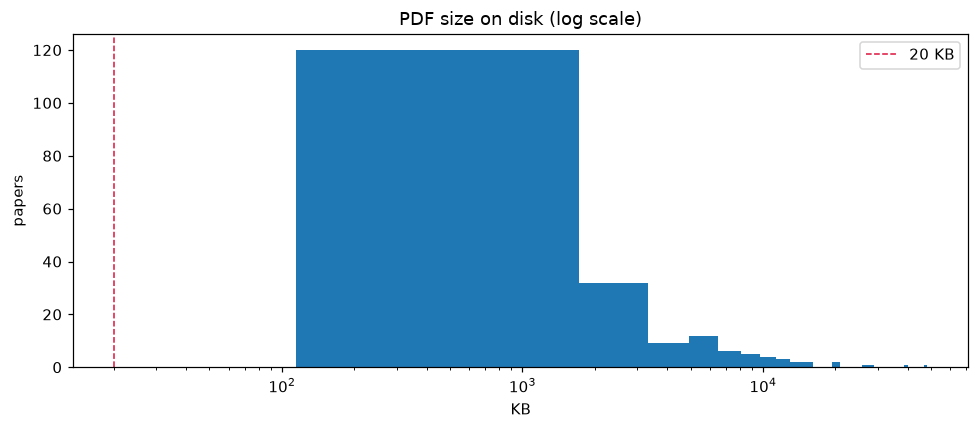

,papers
complete but no text,0
complete but PDF missing on disk,0
PDF on disk isn't a valid PDF (bad header),0
PDF under 20 KB (likely partial download),0
extracted but no text,0
has text but not marked extracted,0
download failed but marked complete,0
pdf_url points to a different paper,0
abs_url points to a different paper,0


In [26]:
# is each PDF really there, and is it really a PDF?
# a download that dies halfway leaves a partial file, and download_pdf then returns
# skipped_exists forever, so broken PDFs never get re-downloaded.
def pdf_check(path):
    if not isinstance(path, str) or not path:
        return pd.Series({"pdf_exists": False, "pdf_kb": np.nan, "pdf_header_ok": False})
    p = Path(path) if Path(path).is_absolute() else next((q for q in [ROOT / path, Path(path)] if q.exists()), ROOT / path)
    if not p.exists():
        return pd.Series({"pdf_exists": False, "pdf_kb": np.nan, "pdf_header_ok": False})
    with open(p, "rb") as f:
        head = f.read(5)
    return pd.Series({"pdf_exists": True, "pdf_kb": p.stat().st_size / 1024, "pdf_header_ok": head == b"%PDF-"})

df = df.join(df["pdf_path"].apply(pdf_check))

has_text = df["extracted_text"].map(lambda v: kind_of_missing(v) is None)
complete = df["ingestion_status"] == "complete"
url_id = lambda u: re.sub(r"(\.pdf)?$", "", str(u).rstrip("/").rsplit("/", 1)[-1])

contradictions = {
    "complete but no text": complete & ~has_text,
    "complete but PDF missing on disk": complete & ~df["pdf_exists"],
    "PDF on disk isn't a valid PDF (bad header)": df["pdf_exists"] & ~df["pdf_header_ok"],
    "PDF under 20 KB (likely partial download)": df["pdf_kb"] < 20,
    "extracted but no text": (df["extraction_status"] == "extracted") & ~has_text,
    "has text but not marked extracted": (df["extraction_status"] != "extracted") & has_text,
    "download failed but marked complete": (df["download_status"] == "failed") & complete,
    "pdf_url points to a different paper": df["pdf_url"].map(url_id).str.replace(r"v\d+$", "", regex=True)
                                            != df["arxiv_id"].str.replace(r"v\d+$", "", regex=True),
    "abs_url points to a different paper": df["abs_url"].map(url_id).str.replace(r"v\d+$", "", regex=True)
                                            != df["arxiv_id"].str.replace(r"v\d+$", "", regex=True),
}
contra = pd.Series({k: int(v.sum()) for k, v in contradictions.items()}, name="papers")
F["contradictions"] = contra[contra > 0].to_dict()
F["pdf_kb_median"] = df["pdf_kb"].median()

fig, ax = plt.subplots()
ax.hist(df["pdf_kb"].dropna().clip(lower=1), bins=30)
ax.set_xscale("log"); ax.axvline(20, color="crimson", ls="--", lw=1, label="20 KB")
ax.set_title("PDF size on disk (log scale)"); ax.set_xlabel("KB"); ax.set_ylabel("papers"); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / "dq_pdf_sizes.png"); plt.show()
contra.to_frame()

## 4. Duplicates

The pipeline deduplicates on `arxiv_id`, which includes the version (`2609.30264v1`). A revised paper comes back as `v2` with a new ID and gets ingested a second time. I also check for copies that don't share an ID at all: identical text, identical abstracts, and near-identical titles (the same work submitted twice, or a paper and its workshop version).

In [27]:
df["base_id"] = df["arxiv_id"].str.replace(r"v\d+$", "", regex=True)
norm = lambda s: re.sub(r"\s+", " ", re.sub(r"[^a-z0-9 ]", " ", str(s).lower())).strip()
md5 = lambda s: hashlib.md5(s.encode()).hexdigest() if isinstance(s, str) and s.strip() else None
df["title_norm"] = df["title"].map(norm)
df["abstract_hash"] = df["abstract"].map(lambda s: md5(norm(s)) if isinstance(s, str) else None)
df["text_hash"] = df["extracted_text"].map(md5)

dup_checks = {
    "exact arxiv_id": df["arxiv_id"].duplicated(keep=False),
    "same paper, different version": df["base_id"].duplicated(keep=False),
    "same normalized title": df["title_norm"].duplicated(keep=False),
    "same abstract": df["abstract_hash"].notna() & df["abstract_hash"].duplicated(keep=False),
    "identical extracted text": df["text_hash"].notna() & df["text_hash"].duplicated(keep=False),
}

# near-duplicate titles: pairwise similarity. Fine up to a few thousand papers.
NEAR_DUP = 0.92
titles = df["title_norm"].tolist()
near_pairs = []
if len(titles) <= 3000:
    for i in range(len(titles)):
        for j in range(i + 1, len(titles)):
            if titles[i] != titles[j] and abs(len(titles[i]) - len(titles[j])) < 20:
                r = SequenceMatcher(None, titles[i], titles[j]).ratio()
                if r >= NEAR_DUP:
                    near_pairs.append((df["arxiv_id"].iat[i], df["arxiv_id"].iat[j], round(r, 3), df["title"].iat[i][:70]))
else:
    print("skipping near-duplicate titles: too many papers for pairwise comparison")

dups = pd.Series({k: int(v.sum()) for k, v in dup_checks.items()}, name="papers involved")
dups[f"near-duplicate titles (>= {NEAR_DUP:.0%} similar)"] = len({p for a, b, *_ in near_pairs for p in (a, b)})
F["duplicates"] = dups[dups > 0].to_dict()
dups.to_frame()

,papers involved
exact arxiv_id,0
"same paper, different version",0
same normalized title,0
same abstract,0
identical extracted text,0
near-duplicate titles (>= 92% similar),0


In [28]:
# show every duplicate group so we can decide which copy to keep
any_dup = np.logical_or.reduce(list(dup_checks.values()))
if any_dup.any():
    display(df.loc[any_dup, ["arxiv_id", "base_id", "title", "published", "updated", "ingestion_status"]].sort_values("base_id"))
if near_pairs:
    display(pd.DataFrame(near_pairs, columns=["id_a", "id_b", "similarity", "title"]))
if not any_dup.any() and not near_pairs:
    print("no duplicates of any kind")

no duplicates of any kind


## 5. Validity: are the values well-formed?

These are the checks that catch bad data that isn't missing: malformed IDs, impossible dates, and author lists that picked up affiliations or repeated names. The live cs.AI listing already has examples of both of the last two.

In [29]:
now = pd.Timestamp.now(tz="UTC")
CAT_RE = r"[a-z\-]+(\.[A-Za-z\-]+)?"

def author_problems(authors):
    if not isinstance(authors, list):
        return []
    out = []
    if len(authors) != len(set(authors)): out.append("repeated name")
    for a in authors:
        if not str(a).strip(): out.append("empty name")
        elif re.search(r"\d|@|university|institute|dept|department|lab\b|school", str(a), re.I): out.append("affiliation in name")
        elif len(str(a).split()) > 5: out.append("name over 5 words")
    return sorted(set(out))

df["author_issues"] = df["authors"].map(author_problems)
df["n_authors"] = df["authors"].map(lambda a: len(a) if isinstance(a, list) else 0)

validity_checks = {
    "arxiv_id not in 2609.12345v1 format": ~df["arxiv_id"].fillna("").str.fullmatch(r"\d{4}\.\d{4,5}v\d+"),
    "category code malformed": df["categories"].map(lambda cs: any(not re.fullmatch(CAT_RE, c) for c in cs) if isinstance(cs, list) else True),
    "primary_category not in categories": df.apply(lambda r: r["primary_category"] not in (r["categories"] or []), axis=1),
    "updated before published": df["updated"] < df["published"],
    "published in the future": df["published"] > now,
    "published before 1991 (arXiv's start)": df["published"] < pd.Timestamp("1991-08-01", tz="UTC"),
    "title under 3 words": df["title"].fillna("").str.split().str.len() < 3,
    "abstract under 30 words": df["abstract"].fillna("").str.split().str.len() < 30,
    "extracted text under 5,000 chars": df["extracted_text"].fillna("").str.len().between(1, 4999),
    "author list: repeated name": df["author_issues"].map(lambda x: "repeated name" in x),
    "author list: affiliation in a name": df["author_issues"].map(lambda x: "affiliation in name" in x),
    "author list: empty or over-long name": df["author_issues"].map(lambda x: bool({"empty name", "name over 5 words"} & set(x))),
}
valid = pd.Series({k: int(v.sum()) for k, v in validity_checks.items()}, name="papers")
F["validity"] = valid[valid > 0].to_dict()
valid.to_frame()

,papers
arxiv_id not in 2609.12345v1 format,0
category code malformed,0
primary_category not in categories,0
updated before published,0
published in the future,0
published before 1991 (arXiv's start),0
title under 3 words,1
abstract under 30 words,0
"extracted text under 5,000 chars",0
author list: repeated name,0


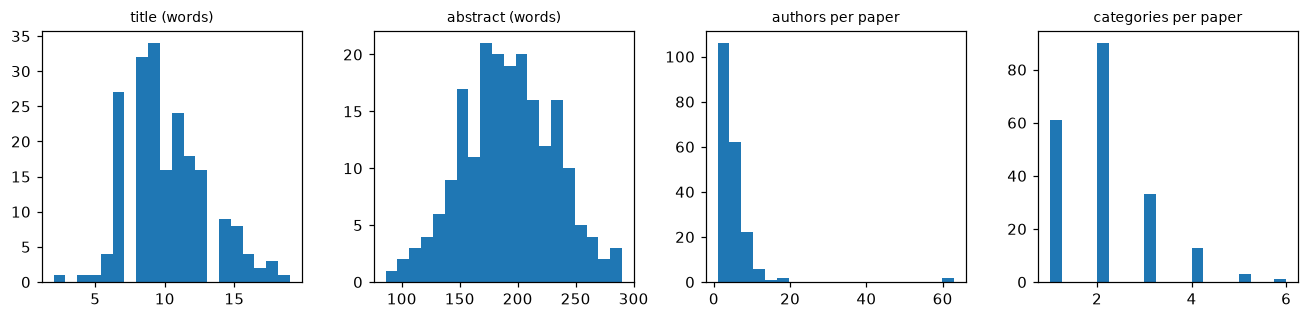

,title (words),abstract (words),authors per paper,categories per paper
count,201.0,201.0,201.0,201.0
mean,10.2,191.9,5.5,2.1
std,2.9,39.3,6.4,1.0
min,2.0,86.0,1.0,1.0
25%,8.0,163.0,3.0,1.0
50%,10.0,192.0,4.0,2.0
75%,12.0,219.0,6.0,2.0
max,19.0,290.0,63.0,6.0


In [30]:
# field length distributions: a quick way to spot truncation or runaway values
lengths = pd.DataFrame({
    "title (words)": df["title"].fillna("").str.split().str.len(),
    "abstract (words)": df["abstract"].fillna("").str.split().str.len(),
    "authors per paper": df["n_authors"],
    "categories per paper": df["categories"].map(lambda c: len(c) if isinstance(c, list) else 0),
})
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, col in zip(axes, lengths):
    ax.hist(lengths[col], bins=20); ax.set_title(col, fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR / "dq_field_lengths.png"); plt.show()
lengths.describe().round(1)

In [31]:
# look at every flagged author list by hand; the rules above are heuristics
flagged = df[df["author_issues"].str.len() > 0]
flagged[["arxiv_id", "authors", "author_issues"]] if len(flagged) else print("no author list issues")

,arxiv_id,authors,author_issues
124,2609.30292v1,"[Fanji Yang (Guizhou University of Finance and Economics), Huiyao Chen (Harb...",[affiliation in name]


## 6. Per-paper flags

Every check above, one row per paper, saved to `data/data_quality_flags.csv`. This lets the next person filter out bad papers or re-ingest specific IDs without rerunning the notebook.

In [32]:
flag_cols = {**{f"consistency: {k}": v for k, v in contradictions.items()},
             **{f"duplicate: {k}": v for k, v in dup_checks.items()},
             **{f"validity: {k}": v for k, v in validity_checks.items()}}
flags = pd.DataFrame({k: v.fillna(False).astype(bool) for k, v in flag_cols.items()})
flags.insert(0, "arxiv_id", df["arxiv_id"])
flags["n_flags"] = flags.drop(columns="arxiv_id").sum(axis=1)
flags["flags"] = flags.drop(columns=["arxiv_id", "n_flags"]).apply(lambda r: "; ".join(r.index[r]), axis=1)

out = ROOT / "data/data_quality_flags.csv"
flags[["arxiv_id", "n_flags", "flags"]].to_csv(out, index=False)
F["papers_flagged"] = int((flags["n_flags"] > 0).sum())
print(f"wrote {out}: {F['papers_flagged']} of {len(flags)} papers have at least one flag")
flags.loc[flags["n_flags"] > 0, ["arxiv_id", "n_flags", "flags"]].sort_values("n_flags", ascending=False).head(20)

wrote ../data/data_quality_flags.csv: 2 of 201 papers have at least one flag


,arxiv_id,n_flags,flags
124,2609.30292v1,1,validity: author list: affiliation in a name
132,2609.30352v1,1,validity: title under 3 words


## 7. Preprocessed output (if it exists)

`src/preprocessing` writes `data/papers_clean.parquet`. This checks that preprocessing didn't introduce new problems: rows dropped without explanation, duplicate IDs, or empty `body_text`.

In [33]:
if CLEAN_PATH.exists():
    clean = pd.read_parquet(CLEAN_PATH)
    raw_base = set(df["base_id"])
    clean_base = set(clean["arxiv_id"].str.replace(r"v\d+$", "", regex=True))
    body = clean["body_text"] if "body_text" in clean else pd.Series(dtype=str)
    clean_checks = {
        "rows in / out": f"{len(df)} / {len(clean)}",
        "papers dropped entirely (base id gone)": len(raw_base - clean_base),
        "papers that appeared from nowhere": len(clean_base - raw_base),
        "duplicate arxiv_id after preprocessing": int(clean["arxiv_id"].duplicated().sum()),
        "empty body_text": int(body.map(lambda v: kind_of_missing(v) is not None).sum()) if len(body) else "no body_text column",
        "columns with nulls": clean.columns[clean.isna().any()].tolist() or "none",
    }
    F["clean_checks"] = clean_checks
    display(pd.Series(clean_checks, name="value").to_frame())
else:
    print(f"{CLEAN_PATH} not found; run `python -m src.preprocessing.cli` from the project root to include this section")

../data/papers_clean.parquet not found; run `python -m src.preprocessing.cli` from the project root to include this section


## 8. Findings

Generated from the numbers above. Copy the printed table into the issue or the writeup.

In [34]:
ACTIONS = {  # what to do if a check finds something
    "schema": "fix the writer in src/ingestion/dataset.py so types match before anything downstream relies on them",
    "missing": "check whether each gap is expected (e.g. failed download); unexpected ones point to a pipeline bug",
    "contradictions": "delete the bad PDFs and set those rows back to partial so the pipeline retries them",
    "duplicates": "keep the latest version per base_id (src/preprocessing/metadata.py already does this for versions)",
    "validity": "review flagged rows in data/data_quality_flags.csv; fix at ingestion if it's systematic",
}
def fmt(v):
    if isinstance(v, dict): return "; ".join(f"{k}: {n}" for k, n in v.items())
    if isinstance(v, list): return ", ".join(map(str, v))
    return str(v)
def row(check, value, key):
    ok = not value
    return f"| {check} | {'none' if ok else fmt(value)} | {'no action; the check stays for larger pulls' if ok else ACTIONS[key]} |"

span_h = (F["date_max"] - F["date_min"]).total_seconds() / 3600
lines = [
    f"**Corpus:** {F['rows']} papers, published {F['date_min']:%Y-%m-%d %H:%M} to {F['date_max']:%Y-%m-%d %H:%M} UTC "
    f"({span_h/24:.1f} days)." if span_h >= 48 else
    f"**Corpus:** {F['rows']} papers, published {F['date_min']:%Y-%m-%d %H:%M} to {F['date_max']:%Y-%m-%d %H:%M} UTC ({span_h:.0f} hours).",
    "",
    "| check | result | what we do about it |",
    "|---|---|---|",
    row("schema matches the pipeline", F["schema_problems"], "schema"),
    row("missing values (null, blank, or empty list)", F["missing"], "missing"),
    row("status / file / URL contradictions", F["contradictions"], "contradictions"),
    row("duplicates (ID, version, title, abstract, text)", F["duplicates"], "duplicates"),
    row("invalid values", F["validity"], "validity"),
    f"| papers with at least one flag | {F['papers_flagged']} of {F['rows']} | see data/data_quality_flags.csv |",
]
if F["missing_hidden"]:
    lines.append(f"\n{F['missing_hidden']} missing values were blank strings or empty lists that `isna()` would not have caught.")
if "clean_checks" in F:
    lines.append(f"\nPreprocessed output: {fmt(F['clean_checks'])}")
print("\n".join(lines))

**Corpus:** 201 papers, published 2026-09-25 13:04 to 2026-09-28 04:00 UTC (2.6 days).

| check | result | what we do about it |
|---|---|---|
| schema matches the pipeline | none | no action; the check stays for larger pulls |
| missing values (null, blank, or empty list) | none | no action; the check stays for larger pulls |
| status / file / URL contradictions | none | no action; the check stays for larger pulls |
| duplicates (ID, version, title, abstract, text) | none | no action; the check stays for larger pulls |
| invalid values | title under 3 words: 1; author list: affiliation in a name: 1 | review flagged rows in data/data_quality_flags.csv; fix at ingestion if it's systematic |
| papers with at least one flag | 2 of 201 | see data/data_quality_flags.csv |
